# Week 12 - Kernel Methods (solution)

Solution author: Lukas Hedegaard (lh@eng.au.dk)

Learning contents:
* Kernel Regression
    * Compute Gram Matrix
    * Estimate the target values for a new set of data points
    * Plot the (x_new, t_new)-pairs on top of the original data
    * Play around with the kernel $\sigma$. How does the fit look using $\sigma=1$ as compared to  $\sigma=10$?


In [3]:
# Dependencies
#import numpy as np
#import scipy
#from sklearn.datasets import load_boston
#from sklearn.decomposition import PCA
#import matplotlib.pyplot as plt
#import seaborn as sns; sns.set();
import numpy as np
import pandas as pd
import scipy
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns; sns.set();

# 1) Kernel Regression

We'll be working with two variable from the [Boston housing dataset](https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html)

In [ ]:
#dataset = load_boston()
#x = dataset.data[:,12] # LSTAT: % lower status of the population.
#t = dataset.target # MEDV: Median value of owner-occupied homes in $1000s.

In [4]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

x = data[:,12] # LSTAT: % lower status of the population.
t = target # MEDV: Median value of owner-occupied homes in $1000s.

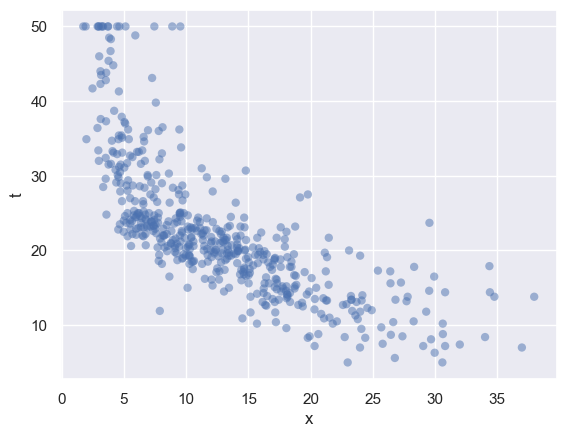

In [5]:
def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data, target,  edgecolor='none', alpha=alpha)
    plt.xlabel('x')
    plt.ylabel('t')

# Let's plot all the data in 2D
plot_scatter(x, t)

## 1.1) Compute the kernel gram matrix
Do it using the Gaussian Kernel based on Euclidean distance.

Use $\sigma = 2$

First, perform the computation for the 5 first samples. Then do it for all samples. What is the shape of the Gram matrix for all samples?

In [6]:
sigma = 2

In [7]:
def gram_matrix(X1, X2=None, sigma = 2):
    if X2 is None:
        X2 = X1

    n_x1 = X1.shape[0]
    n_x2 = X2.shape[0]

    n_dim = X1.shape[-1] if len(X1.shape) > 1 else 1

    if len(X1.shape) == 1:
        X1 = np.expand_dims(X1, axis=-1)
    if len(X2.shape) == 1:
        X2 = np.expand_dims(X2, axis=-1)

    X1_broad = np.repeat(X1[:,np.newaxis,:], n_x2, axis=1)
    X2_broad = np.swapaxes(
        np.repeat(X2[:,np.newaxis,:], n_x1, axis=1),
        0,1
    )

    K = np.exp(
        - np.linalg.norm(
            X1_broad - X2_broad,
            axis=-1
          )**2
        /
        (2*sigma**2)
    )
    return K

In [8]:
# 5 first samples
gram_matrix(x[:5], sigma=2)

array([[1.        , 0.11495667, 0.89331814, 0.59440166, 0.98480414],
       [0.11495667, 1.        , 0.03823467, 0.0081887 , 0.16291731],
       [0.89331814, 0.03823467, 1.        , 0.86198923, 0.80957165],
       [0.59440166, 0.0081887 , 0.86198923, 1.        , 0.48967543],
       [0.98480414, 0.16291731, 0.80957165, 0.48967543, 1.        ]])

In [9]:
K = gram_matrix(x, sigma=2)
print("shape = {}".format(K.shape))
K

shape = (506, 506)


array([[1.        , 0.11495667, 0.89331814, ..., 0.94700586, 0.7548396 ,
        0.3495006 ],
       [0.11495667, 1.        , 0.03823467, ..., 0.21626517, 0.41294123,
        0.82000077],
       [0.89331814, 0.03823467, 1.        , ..., 0.7232412 , 0.47221896,
        0.15679556],
       ...,
       [0.94700586, 0.21626517, 0.7232412 , ..., 1.        , 0.91557774,
        0.53408515],
       [0.7548396 , 0.41294123, 0.47221896, ..., 0.91557774, 1.        ,
        0.78270454],
       [0.3495006 , 0.82000077, 0.15679556, ..., 0.53408515, 0.78270454,
        1.        ]])

## 1.2) Estimate the target values for a new set of data points
Use a regularisation term of lambda = 0.001

In [10]:
l = 0.001 # lambda
sigma = 2
x_new = np.linspace(0, 40, 100) # Range in which to compute estimated values

In [11]:
t_new = gram_matrix(x_new, x, sigma=sigma) @ np.linalg.inv(gram_matrix(x, sigma=sigma) + l*np.eye(len(x))) @ t

In [12]:
print(t_new)

[70.65814877 66.54493624 60.40011825 53.76864336 48.11766362 44.36783446
 42.61210592 42.1546034  41.87313991 40.75728657 38.37490877 35.03779999
 31.58224143 28.88780079 27.40917481 26.98876155 27.04157118 26.96574512
 26.49346186 25.75912341 25.07956743 24.64922381 24.39283367 24.06703281
 23.49283897 22.70888565 21.92692019 21.3521622  21.03717816 20.88461317
 20.76676725 20.63218749 20.50439149 20.39663867 20.24666985 19.94377407
 19.41995441 18.71345063 17.94634178 17.24629944 16.69144849 16.31937826
 16.16273802 16.24292589 16.50684984 16.77441046 16.78378808 16.34355022
 15.48988202 14.51139023 13.79073358 13.55864091 13.73811015 13.99911123
 13.98788365 13.56444332 12.88033123 12.25301986 11.94168953 11.98790973
 12.21965368 12.39117834 12.34474372 12.08826885 11.76145835 11.54030564
 11.55137463 11.8334048  12.3377656  12.94226114 13.46940618 13.72175253
 13.54348022 12.88885292 11.85370422 10.63678623  9.44458104  8.40141341
  7.53291679  6.84077406  6.41205129  6.46497703  7

## 1.3) Plot the (x_new, t_new)-pairs on top of the original data
Hint: You can use `seaborn.lineplot`

c:\Users\au682451\AppData\Local\anaconda3\envs\work\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\au682451\AppData\Local\anaconda3\envs\work\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='x', ylabel='t'>

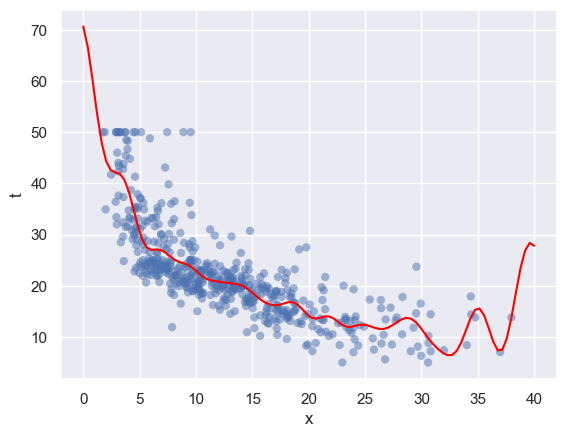

In [13]:
plot_scatter(x, t)
sns.lineplot(x=x_new, y=t_new, color='red')

## 1.4) Play around with the kernel $\sigma$. How does the fit look using $\sigma=1$ as compared to  $\sigma=10$?

c:\Users\au682451\AppData\Local\anaconda3\envs\work\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\au682451\AppData\Local\anaconda3\envs\work\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='x', ylabel='t'>

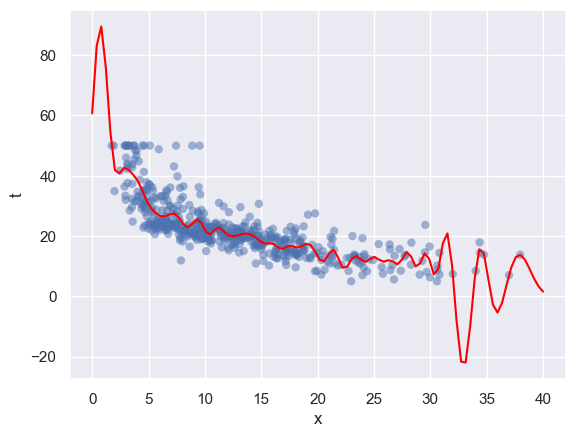

In [14]:
sigma = 1
t_new = gram_matrix(x_new, x, sigma=sigma) @ np.linalg.inv(gram_matrix(x, sigma=sigma) + l*np.eye(len(x))) @ t
plot_scatter(x, t)
sns.lineplot(x=x_new, y=t_new, color='red')

c:\Users\au682451\AppData\Local\anaconda3\envs\work\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\au682451\AppData\Local\anaconda3\envs\work\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='x', ylabel='t'>

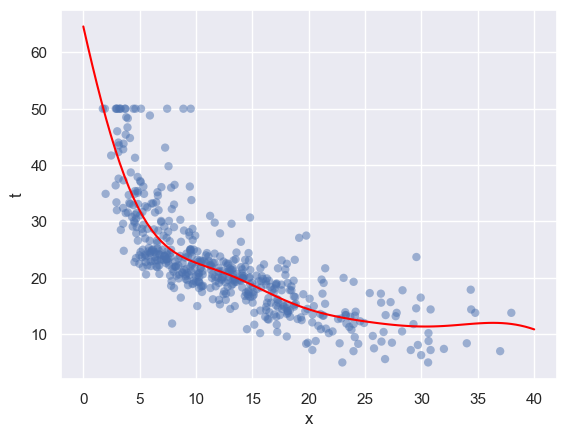

In [15]:
sigma = 10
t_new = gram_matrix(x_new, x, sigma=sigma) @ np.linalg.inv(gram_matrix(x, sigma=sigma) + l*np.eye(len(x))) @ t
plot_scatter(x, t)
sns.lineplot(x=x_new, y=t_new, color='red')

A high value of sigma will "smoothen" the curve as compared to a low one. This is becauses a larger sigma yields a wider kernel, whereby values further away contribute more to the target estimate.

![title](https://vignette.wikia.nocookie.net/math-physics-problems/images/6/6f/Heat_kernel.png/revision/latest?cb=20180329171326)